# MSL Trust Study - Auswertung

Reproduzierbare Auswertung der Trust-Studie zum MCP Sandbox Layer.

- Eingang: [../data/](../data/)
- Ausgang: Plots nach [../figures/](../figures/), Aggregat-Tabellen nach [../tables/](../tables/)

Pool: 18 Teilnehmer, Within-Subject 8 Cases mal 3 Varianten mal 3 Counterbalance-Designs.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from helpers import (
    load_long, load_wide, load_sus, load_post_feedback, load_plans, load_cases, load_designs,
    bootstrap_mean_ci, wilson_ci, effect_r, save_plot,
    VARIANT_ORDER, VARIANT_COLOR, GROUP_COLOR, ITEM_LABELS,
)

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150, 'font.size': 10})

long_df = load_long()
wide_df = load_wide()
sus_df = load_sus()
pf_df = load_post_feedback()
plans_df = load_plans()
cases_df = load_cases()
designs_df = load_designs()

print(f'long {long_df.shape}, wide {wide_df.shape}, sus {sus_df.shape}, plans {plans_df.shape}')

long (144, 26), wide (18, 78), sus (18, 14), plans (1140, 15)


## Deskriptiv pro Variante

Mittelwert und Bootstrap-95-Prozent-CI für die vier Likert-Items pro Variante.

In [2]:
rows = []
for var in VARIANT_ORDER:
    sub = long_df[long_df['variant'] == var]
    for col, label in ITEM_LABELS.items():
        m, lo, hi = bootstrap_mean_ci(sub[col])
        rows.append({'variant': var, 'item': label, 'mean': round(m, 2), 'ci_lo': round(lo, 2), 'ci_hi': round(hi, 2), 'n': sub[col].notna().sum()})
desc_table = pd.DataFrame(rows)
desc_table

,variant,item,mean,ci_lo,ci_hi,n
0,summary,Trust,5.51,5.00,6.00,49
1,summary,Confidence,6.27,5.88,6.59,49
2,summary,Transparency,6.06,5.59,6.47,49
3,summary,Control,5.31,4.71,5.88,49
4,diff,Trust,5.96,5.54,6.35,48
5,diff,Confidence,6.33,5.96,6.67,48
6,diff,Transparency,6.42,6.12,6.67,48
7,diff,Control,5.52,5.02,6.00,48
8,diff_risk,Trust,5.98,5.45,6.45,47
9,diff_risk,Confidence,6.38,6.04,6.68,47


## Mittelwert und Standardabweichung pro Variante

Direkter Blick auf Mean, SD, Median und Spannweite vor der Inferenzstatistik.

In [3]:
rows = []
for col, label in ITEM_LABELS.items():
    for var in VARIANT_ORDER:
        s = long_df[long_df['variant'] == var][col].dropna()
        rows.append({'item': label, 'variant': var, 'n': len(s),
                     'mean': round(s.mean(), 2), 'sd': round(s.std(ddof=1), 2),
                     'median': round(s.median(), 1), 'min': int(s.min()), 'max': int(s.max())})
mean_sd_table = pd.DataFrame(rows)
mean_sd_table

,item,variant,n,mean,sd,median,min,max
0,Trust,summary,49,5.51,1.83,6.0,1,7
1,Trust,diff,48,5.96,1.47,6.5,2,7
2,Trust,diff_risk,47,5.98,1.76,7.0,1,7
3,Confidence,summary,49,6.27,1.30,7.0,3,7
4,Confidence,diff,48,6.33,1.29,7.0,2,7
5,Confidence,diff_risk,47,6.38,1.15,7.0,2,7
6,Transparency,summary,49,6.06,1.55,7.0,1,7
7,Transparency,diff,48,6.42,0.96,7.0,2,7
8,Transparency,diff_risk,47,6.36,1.15,7.0,2,7
9,Control,summary,49,5.31,2.09,6.0,1,7


## SUS Mean und SD nach Gruppe

In [4]:
sus_rows = []
for g in ['professional_dev', 'citizen_dev']:
    s = sus_df[sus_df['group'] == g]['sus_score']
    sus_rows.append({'group': g, 'n': len(s), 'mean': round(s.mean(), 2),
                     'sd': round(s.std(ddof=1), 2), 'median': round(s.median(), 2),
                     'min': round(s.min(), 2), 'max': round(s.max(), 2)})
s = sus_df['sus_score']
sus_rows.append({'group': 'overall', 'n': len(s), 'mean': round(s.mean(), 2),
                 'sd': round(s.std(ddof=1), 2), 'median': round(s.median(), 2),
                 'min': round(s.min(), 2), 'max': round(s.max(), 2)})
sus_mean_sd = pd.DataFrame(sus_rows)
sus_mean_sd

,group,n,mean,sd,median,min,max
0,professional_dev,10,75.25,20.39,78.75,32.5,100.0
1,citizen_dev,8,76.56,18.71,80.00,47.5,100.0
2,overall,18,75.83,19.10,78.75,32.5,100.0


## Inferenz, Friedman und Wilcoxon

Pro Item Friedman-Omnibus über Pnn-aggregierte Werte je Variante, danach paarweise Wilcoxon mit Bonferroni-Korrektur (Friedman 1937, Wilcoxon 1945). Effektgrößen Kendall's W und Rosenthal's r in der Ergebnis-Tabelle.

In [5]:
results = []
for col, label in ITEM_LABELS.items():
    pid_var = long_df.groupby(['pid', 'variant'])[col].mean().unstack()[VARIANT_ORDER].dropna()
    chi2, p = stats.friedmanchisquare(pid_var['summary'], pid_var['diff'], pid_var['diff_risk'])
    n = len(pid_var)
    k = 3
    kendall_w = chi2 / (n * (k - 1))
    results.append({'item': label, 'test': 'friedman', 'stat': round(chi2, 2), 'p': round(p, 4), 'n': n, 'effect': round(kendall_w, 3), 'effect_kind': 'kendall_w'})
    pairs = [('summary','diff'), ('summary','diff_risk'), ('diff','diff_risk')]
    for a, b in pairs:
        try:
            res = stats.wilcoxon(pid_var[a], pid_var[b], zero_method='wilcox')
            r_eff = effect_r(stats.norm.ppf(1 - res.pvalue / 2), n)
            results.append({'item': label, 'test': f'wilcoxon {a} vs {b}', 'stat': round(res.statistic, 2), 'p': round(min(1.0, res.pvalue * 3), 4), 'n': n, 'effect': round(r_eff, 3), 'effect_kind': 'rosenthal_r'})
        except Exception as e:
            results.append({'item': label, 'test': f'wilcoxon {a} vs {b}', 'stat': np.nan, 'p': np.nan, 'n': n, 'effect': np.nan, 'effect_kind': 'rosenthal_r', 'err': str(e)})
inference_table = pd.DataFrame(results)
inference_table

,item,test,stat,p,n,effect,effect_kind
0,Trust,friedman,5.93,0.0515,18,0.165,kendall_w
1,Trust,wilcoxon summary vs diff,37.50,0.6030,18,0.301,rosenthal_r
2,Trust,wilcoxon summary vs diff_risk,18.00,0.0902,18,0.511,rosenthal_r
3,Trust,wilcoxon diff vs diff_risk,51.00,1.0000,18,0.022,rosenthal_r
4,Confidence,friedman,1.06,0.5896,18,0.029,kendall_w
5,Confidence,wilcoxon summary vs diff,27.50,1.0000,18,0.213,rosenthal_r
6,Confidence,wilcoxon summary vs diff_risk,31.00,1.0000,18,0.149,rosenthal_r
7,Confidence,wilcoxon diff vs diff_risk,40.00,1.0000,18,0.185,rosenthal_r
8,Transparency,friedman,1.34,0.5105,18,0.037,kendall_w
9,Transparency,wilcoxon summary vs diff,44.50,1.0000,18,0.208,rosenthal_r


## Plot 01, SUS Overall

SUS-Score-Verteilung mit Mittelwert (Brooke 1996, Bangor 2008).

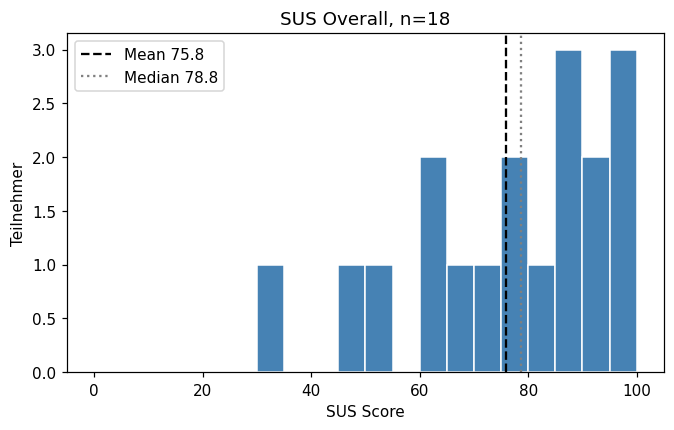

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sus_df['sus_score'], bins=np.arange(0, 105, 5), color='steelblue', edgecolor='white')
m = sus_df['sus_score'].mean()
med = sus_df['sus_score'].median()
ax.axvline(m, color='black', linestyle='--', label=f'Mean {m:.1f}')
ax.axvline(med, color='gray', linestyle=':', label=f'Median {med:.1f}')
ax.set_xlabel('SUS Score')
ax.set_ylabel('Teilnehmer')
ax.set_title('SUS Overall, n=18')
ax.legend()
save_plot(fig, '01-sus-overall')
plt.show()

## Plot 02, Ratings by Variant

Vier Likert-Items als Boxplot pro Variante.

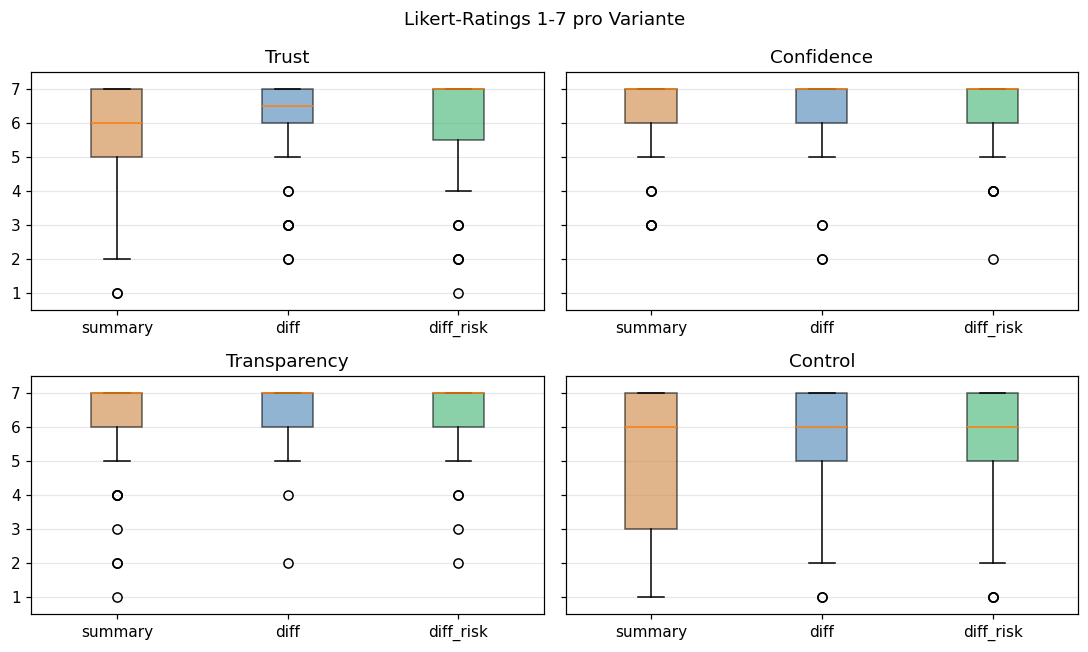

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharey=True)
for ax, (col, label) in zip(axes.flat, ITEM_LABELS.items()):
    data = [long_df[long_df['variant'] == v][col].dropna().values for v in VARIANT_ORDER]
    bp = ax.boxplot(data, tick_labels=VARIANT_ORDER, patch_artist=True)
    for patch, var in zip(bp['boxes'], VARIANT_ORDER):
        patch.set_facecolor(VARIANT_COLOR[var])
        patch.set_alpha(0.6)
    ax.set_title(label)
    ax.set_ylim(0.5, 7.5)
    ax.grid(True, axis='y', alpha=0.3)
fig.suptitle('Likert-Ratings 1-7 pro Variante')
fig.tight_layout()
save_plot(fig, '02-ratings-by-variant')
plt.show()

## Plot 03, Decision Time by Variant

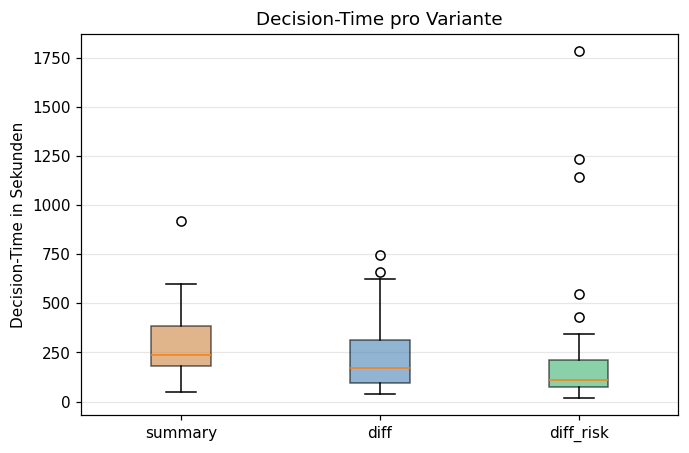

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
data = [long_df[long_df['variant'] == v]['decision_time_s'].dropna().values for v in VARIANT_ORDER]
bp = ax.boxplot(data, tick_labels=VARIANT_ORDER, patch_artist=True)
for patch, var in zip(bp['boxes'], VARIANT_ORDER):
    patch.set_facecolor(VARIANT_COLOR[var])
    patch.set_alpha(0.6)
ax.set_ylabel('Decision-Time in Sekunden')
ax.set_title('Decision-Time pro Variante')
ax.grid(True, axis='y', alpha=0.3)
save_plot(fig, '03-time-by-variant')
plt.show()

## Plot 04, Tech Success by Case

Pro Case Anteil tech-erfolgreich plus Wilson-CI (Wilson 1927).

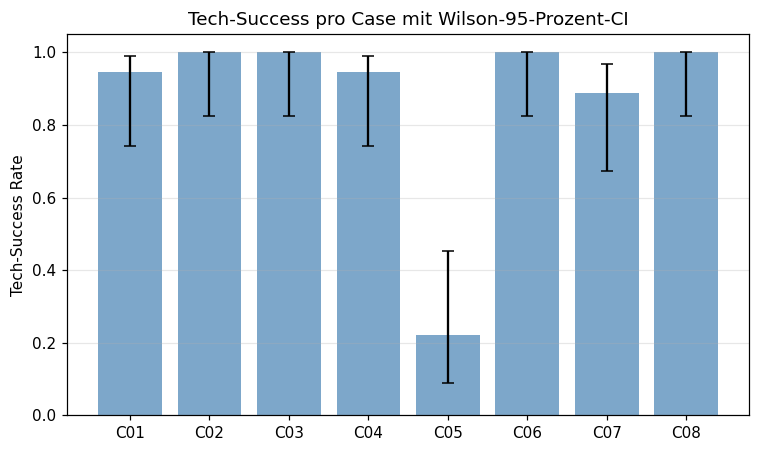

In [9]:
by_case = long_df.groupby('case').agg(succ=('tech_succeeded', 'sum'), n=('tech_succeeded', 'count')).reset_index()
by_case[['p', 'lo', 'hi']] = by_case.apply(lambda r: pd.Series(wilson_ci(int(r['succ']), int(r['n']))), axis=1)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(by_case['case'], by_case['p'], color='steelblue', alpha=0.7)
ax.errorbar(by_case['case'], by_case['p'], yerr=[by_case['p'] - by_case['lo'], by_case['hi'] - by_case['p']], fmt='none', color='black', capsize=4)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Tech-Success Rate')
ax.set_title('Tech-Success pro Case mit Wilson-95-Prozent-CI')
ax.grid(True, axis='y', alpha=0.3)
save_plot(fig, '04-tech-success-by-case')
plt.show()

## Plot 05, Trust vs Tech-Success

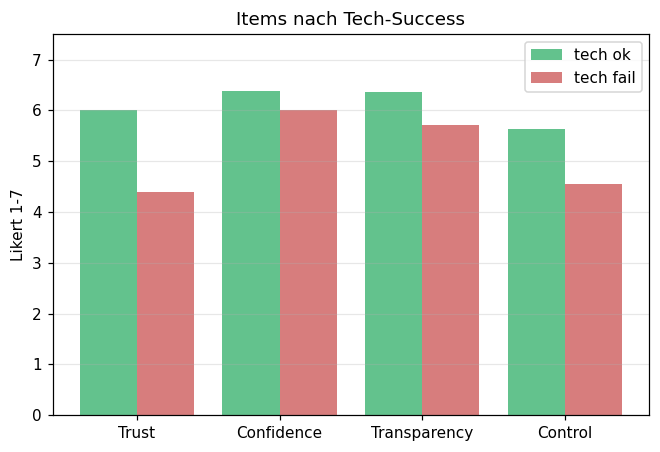

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
items = list(ITEM_LABELS.items())
x = np.arange(len(items))
succ_means = [long_df[long_df['tech_succeeded'] == 1][col].mean() for col, _ in items]
fail_means = [long_df[long_df['tech_succeeded'] == 0][col].mean() for col, _ in items]
ax.bar(x - 0.2, succ_means, width=0.4, label='tech ok', color='mediumseagreen', alpha=0.8)
ax.bar(x + 0.2, fail_means, width=0.4, label='tech fail', color='indianred', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([lbl for _, lbl in items])
ax.set_ylim(0, 7.5)
ax.set_ylabel('Likert 1-7')
ax.set_title('Items nach Tech-Success')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
save_plot(fig, '05-trust-vs-tech')
plt.show()

## Plot 06, Plans Seen vs Decision Time

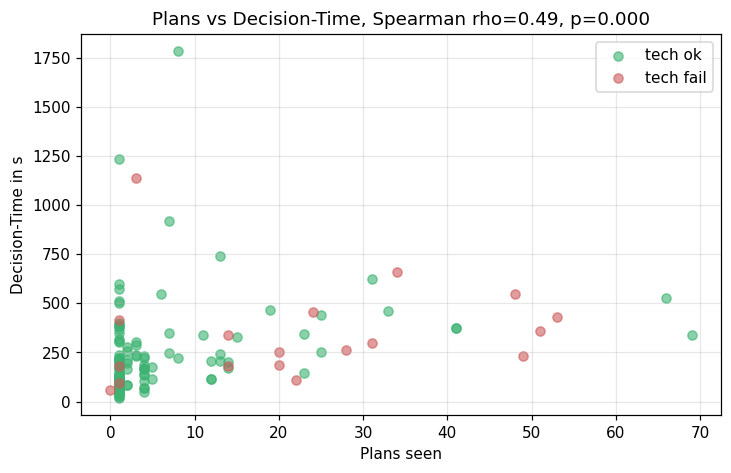

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
succ = long_df[long_df['tech_succeeded'] == 1]
fail = long_df[long_df['tech_succeeded'] == 0]
ax.scatter(succ['plans_seen'], succ['decision_time_s'], color='mediumseagreen', alpha=0.6, label='tech ok')
ax.scatter(fail['plans_seen'], fail['decision_time_s'], color='indianred', alpha=0.6, label='tech fail')
rho, p = stats.spearmanr(long_df['plans_seen'], long_df['decision_time_s'], nan_policy='omit')
ax.set_xlabel('Plans seen')
ax.set_ylabel('Decision-Time in s')
ax.set_title(f'Plans vs Decision-Time, Spearman rho={rho:.2f}, p={p:.3f}')
ax.legend()
ax.grid(True, alpha=0.3)
save_plot(fig, '06-plans-vs-time')
plt.show()

## Plot 07, Trust Spread Individual

Pro Pnn die drei Variant-Trust-Mittelwerte als Heatmap.

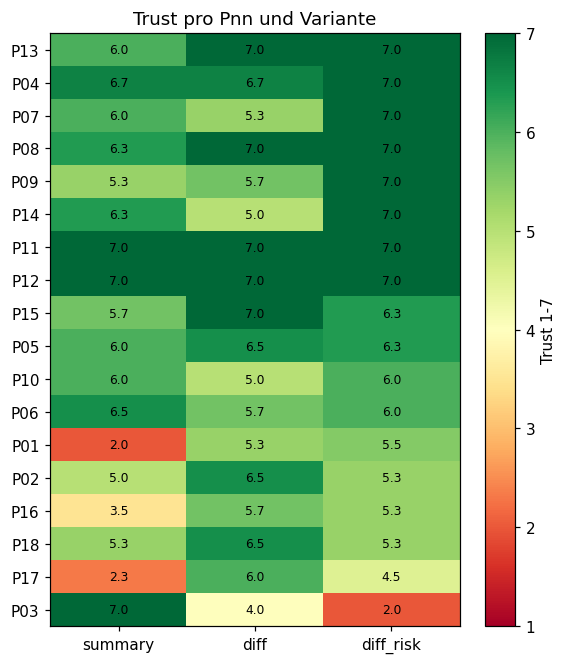

In [12]:
pid_var_trust = long_df.groupby(['pid', 'variant'])['trust_rating'].mean().unstack()[VARIANT_ORDER]
pid_var_trust = pid_var_trust.sort_values('diff_risk', ascending=False)
fig, ax = plt.subplots(figsize=(6, 7))
im = ax.imshow(pid_var_trust.values, cmap='RdYlGn', vmin=1, vmax=7, aspect='auto')
ax.set_yticks(range(len(pid_var_trust)))
ax.set_yticklabels(pid_var_trust.index)
ax.set_xticks(range(3))
ax.set_xticklabels(VARIANT_ORDER)
for i in range(len(pid_var_trust)):
    for j in range(3):
        ax.text(j, i, f'{pid_var_trust.iloc[i, j]:.1f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, label='Trust 1-7')
ax.set_title('Trust pro Pnn und Variante')
save_plot(fig, '07-trust-spread-individual')
plt.show()

## Plot 08, Trust Lift summary nach diff_risk

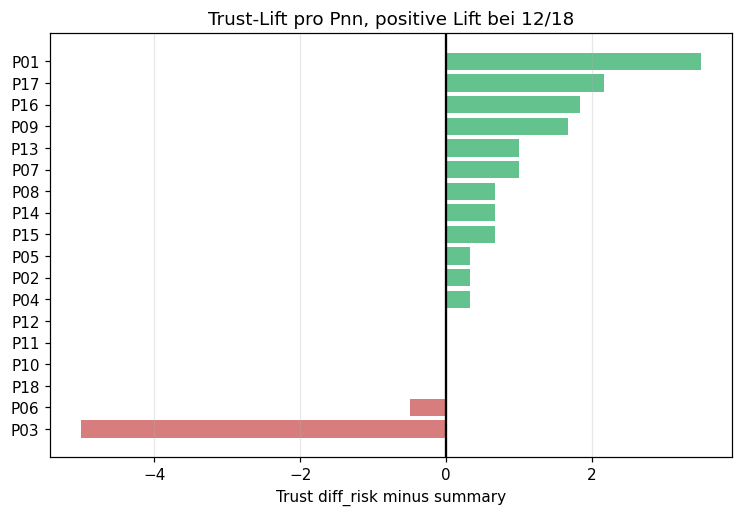

In [13]:
lift = (pid_var_trust['diff_risk'] - pid_var_trust['summary']).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['indianred' if v < 0 else 'mediumseagreen' for v in lift]
ax.barh(lift.index, lift.values, color=colors, alpha=0.8)
ax.axvline(0, color='black')
ax.set_xlabel('Trust diff_risk minus summary')
ax.set_title(f'Trust-Lift pro Pnn, positive Lift bei {(lift > 0).sum()}/18')
ax.grid(True, axis='x', alpha=0.3)
save_plot(fig, '08-trust-lift-individual')
plt.show()

## Plot 09, SUS Individual

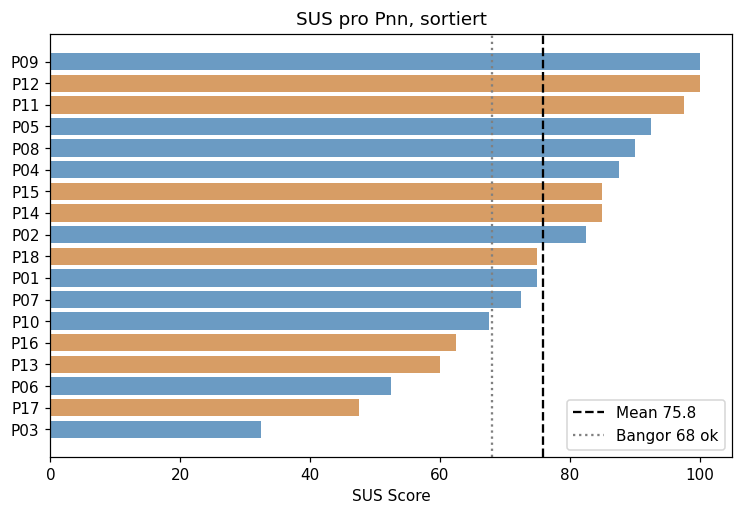

In [14]:
sus_sorted = sus_df.sort_values('sus_score', ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
colors = [GROUP_COLOR[g] for g in sus_sorted['group']]
ax.barh(sus_sorted['pid'], sus_sorted['sus_score'], color=colors, alpha=0.8)
m = sus_df['sus_score'].mean()
ax.axvline(m, color='black', linestyle='--', label=f'Mean {m:.1f}')
ax.axvline(68, color='gray', linestyle=':', label='Bangor 68 ok')
ax.set_xlim(0, 105)
ax.set_xlabel('SUS Score')
ax.set_title('SUS pro Pnn, sortiert')
ax.legend()
save_plot(fig, '09-sus-individual')
plt.show()

## Plot 10, Korrelationsmatrix der vier Items

Spearman-Korrelationen zwischen Trust, Confidence, Transparency, Control.

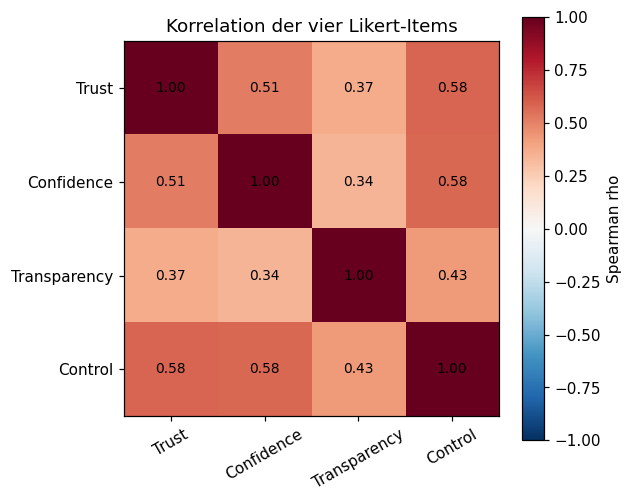

In [15]:
items_df = long_df[list(ITEM_LABELS.keys())].rename(columns=ITEM_LABELS)
corr = items_df.corr(method='spearman')
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=30)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=ax, label='Spearman rho')
ax.set_title('Korrelation der vier Likert-Items')
save_plot(fig, '10-correlation-matrix')
plt.show()

## Plot 11, MSL Approval-Trigger pro Case

Pro Case-Run wird der MSL-Outcome auf Run-Ebene in eine von vier Kategorien klassifiziert: **Approval-Triggered** (User wurde gefragt), **Hard-Blocked** (Validation-Gate-Block), **Auto-Approved** (unter Schwelle, automatisch appliedt), **No-Action** (kein Plan erzeugt, aus Klassifikation ausgeschlossen).

MSL-erkannt (für die Confusion-Matrix) = Approval-Triggered oder Hard-Blocked. TP/TN/FP/FN gilt für den Run als Ganzes:

- **TP**: GT=reject und MSL hat eingegriffen -> korrekt erkanntes Risiko
- **TN**: GT=approve und MSL hat nicht eingegriffen -> korrekt nicht eingegriffen
- **FP**: GT=approve und MSL hat eingegriffen -> fälschlicher Alarm
- **FN**: GT=reject und MSL hat nicht eingegriffen -> verpasste Risiko-Erkennung

           gt      risk  approval_triggered  hard_blocked  auto_approved  \
case                                                                       
C01   approve       low                   0             1             17   
C02   approve       low                   0             0             18   
C03   approve   low_med                   0             0             18   
C04    reject      high                  18             0              0   
C05    reject  med_high                  17             1              0   
C06    reject      high                  18             0              0   
C07    reject      high                  17             0              0   
C08   approve       med                  18             0              0   

      no_action class  
case                   
C01           0    TN  
C02           0    TN  
C03           0    TN  
C04           0    TP  
C05           0    TP  
C06           0    TP  
C07           1    TP  
C08           0    FP  

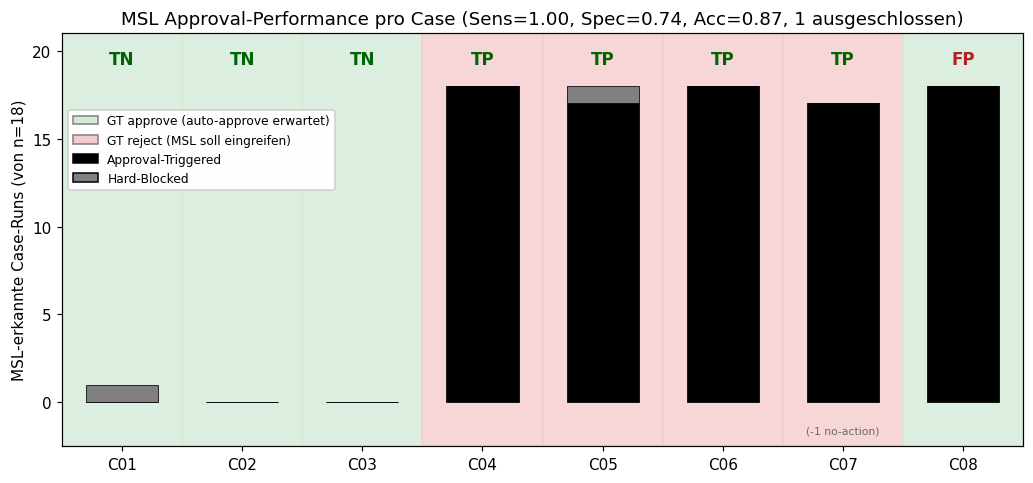

In [16]:
def categorize(row):
    if row['plans_seen'] == 0:
        return 'no_action'
    if (row['plans_approved'] + row['plans_rejected']) > 0:
        return 'approval_triggered'
    if row['tech_succeeded'] == 0:
        return 'hard_blocked'
    return 'auto_approved'

long_df['outcome_cat'] = long_df.apply(categorize, axis=1)
long_df['msl_recognised'] = long_df['outcome_cat'].isin(['approval_triggered', 'hard_blocked']).astype(int)

counts = long_df.groupby(['case', 'outcome_cat']).size().unstack(fill_value=0)
for col in ['approval_triggered', 'hard_blocked', 'auto_approved', 'no_action']:
    if col not in counts: counts[col] = 0

perf = (long_df.groupby('case')
        .agg(gt=('case_gt_decision', 'first'),
             risk=('case_risk_class', 'first'),
             recognised_n=('msl_recognised', 'sum'),
             n_excluded=('outcome_cat', lambda x: (x == 'no_action').sum()),
             n=('msl_recognised', 'size')))
perf = perf.join(counts[['approval_triggered', 'hard_blocked', 'auto_approved', 'no_action']])

def classify(row):
    valid = row['n'] - row['n_excluded']
    if valid == 0: return 'n/a'
    expect_reject = row['gt'] == 'reject'
    actual_recognised = (row['recognised_n'] / valid) >= 0.5
    if expect_reject and actual_recognised: return 'TP'
    if not expect_reject and not actual_recognised: return 'TN'
    if not expect_reject and actual_recognised: return 'FP'
    return 'FN'
perf['class'] = perf.apply(classify, axis=1)

valid = long_df[long_df['outcome_cat'] != 'no_action']
tp = ((valid['case_gt_decision'] == 'reject') & (valid['msl_recognised'] == 1)).sum()
tn = ((valid['case_gt_decision'] == 'approve') & (valid['msl_recognised'] == 0)).sum()
fp = ((valid['case_gt_decision'] == 'approve') & (valid['msl_recognised'] == 1)).sum()
fn = ((valid['case_gt_decision'] == 'reject') & (valid['msl_recognised'] == 0)).sum()
n_excluded = (long_df['outcome_cat'] == 'no_action').sum()
sens = tp / (tp + fn) if (tp + fn) else float('nan')
spec = tn / (tn + fp) if (tn + fp) else float('nan')
acc = (tp + tn) / (tp + tn + fp + fn)

print(perf[['gt', 'risk', 'approval_triggered', 'hard_blocked', 'auto_approved', 'no_action', 'class']])
print(f'\nGültige Trials (n={tp+tn+fp+fn}, ausgeschlossen={n_excluded}): TP={tp}, TN={tn}, FP={fp}, FN={fn}')
print(f'Sensitivität={sens:.3f}, Specificity={spec:.3f}, Accuracy={acc:.3f}')

from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(9.5, 4.5))
cases = perf.index.tolist()
xs = list(range(len(cases)))

for i, c in enumerate(cases):
    bg = '#d4ead7' if perf.loc[c, 'gt'] == 'approve' else '#f4cccc'
    ax.axvspan(i - 0.5, i + 0.5, color=bg, alpha=0.8, zorder=0)

trig = perf['approval_triggered'].values
hb = perf['hard_blocked'].values
ax.bar(xs, trig, color='black', edgecolor='black', linewidth=0.5, width=0.6, zorder=2)
ax.bar(xs, hb, bottom=trig, color='gray', edgecolor='black', linewidth=0.5, width=0.6, zorder=2)

cls_color_map = {'TP': 'darkgreen', 'TN': 'darkgreen', 'FP': 'firebrick', 'FN': 'darkorange', 'n/a': 'dimgray'}
for i, c in enumerate(cases):
    cls = perf.loc[c, 'class']
    ax.text(i, 19, cls, ha='center', va='bottom', fontsize=11, fontweight='bold', color=cls_color_map[cls])

for i, c in enumerate(cases):
    na = int(perf.loc[c, 'no_action'])
    if na > 0:
        ax.text(i, -1.3, f'(-{na} no-action)', ha='center', va='top', fontsize=7, color='dimgray')

ax.set_xticks(xs)
ax.set_xticklabels(cases)
ax.set_ylabel('MSL-erkannte Case-Runs (von n=18)')
ax.set_ylim(-2.5, 21)
ax.set_xlim(-0.5, len(cases) - 0.5)
ax.set_title(f'MSL Approval-Performance pro Case (Sens={sens:.2f}, Spec={spec:.2f}, Acc={acc:.2f}, {n_excluded} ausgeschlossen)')

legend_elements = [
    Patch(facecolor='#d4ead7', edgecolor='gray', label='GT approve (auto-approve erwartet)'),
    Patch(facecolor='#f4cccc', edgecolor='gray', label='GT reject (MSL soll eingreifen)'),
    Patch(facecolor='black', edgecolor='black', label='Approval-Triggered'),
    Patch(facecolor='gray', edgecolor='black', label='Hard-Blocked'),
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.0, 0.83),
          fontsize=8, framealpha=0.95)

fig.tight_layout()
save_plot(fig, '11-decision-confusion-by-variant')
plt.show()

## Plot 12, Forest Plot Variant-Effekte

Differenzen diff minus summary und diff_risk minus summary für jedes Item, mit Bootstrap-95-Prozent-CI.

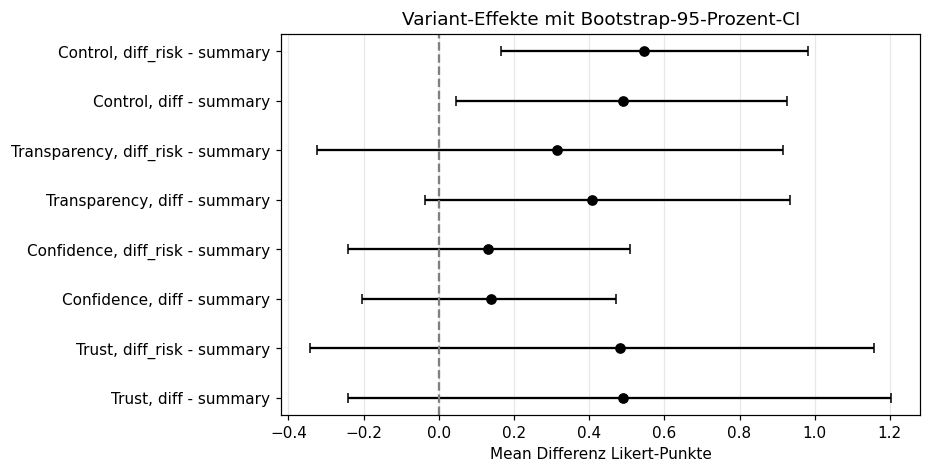

,item,contrast,mean,lo,hi
0,Trust,diff - summary,0.490741,-0.240741,1.203704
1,Trust,diff_risk - summary,0.481481,-0.342593,1.157407
2,Confidence,diff - summary,0.138889,-0.203704,0.472222
3,Confidence,diff_risk - summary,0.129630,-0.240972,0.509259
4,Transparency,diff - summary,0.407407,-0.037269,0.935185
5,Transparency,diff_risk - summary,0.314815,-0.324074,0.916667
6,Control,diff - summary,0.490741,0.046065,0.926157
7,Control,diff_risk - summary,0.546296,0.166667,0.981481


In [17]:
forest_rows = []
for col, label in ITEM_LABELS.items():
    pid_var = long_df.groupby(['pid', 'variant'])[col].mean().unstack()[VARIANT_ORDER].dropna()
    for ref, comp in [('summary', 'diff'), ('summary', 'diff_risk')]:
        m, lo, hi = bootstrap_mean_ci((pid_var[comp] - pid_var[ref]).values)
        forest_rows.append({'item': label, 'contrast': f'{comp} - {ref}', 'mean': m, 'lo': lo, 'hi': hi})
forest = pd.DataFrame(forest_rows)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
y = np.arange(len(forest))
ax.errorbar(forest['mean'], y, xerr=[forest['mean'] - forest['lo'], forest['hi'] - forest['mean']], fmt='o', color='black', capsize=3)
ax.axvline(0, color='gray', linestyle='--')
ax.set_yticks(y)
ax.set_yticklabels([f"{r['item']}, {r['contrast']}" for _, r in forest.iterrows()])
ax.set_xlabel('Mean Differenz Likert-Punkte')
ax.set_title('Variant-Effekte mit Bootstrap-95-Prozent-CI')
ax.grid(True, axis='x', alpha=0.3)
save_plot(fig, '12-forest-variant-effects')
plt.show()
forest

## Plot 13, Counterbalance-Order-Effekt

Trust-Rating der Cases nach Position 1 und Position 8 in der Sequenz, gruppiert nach Design.

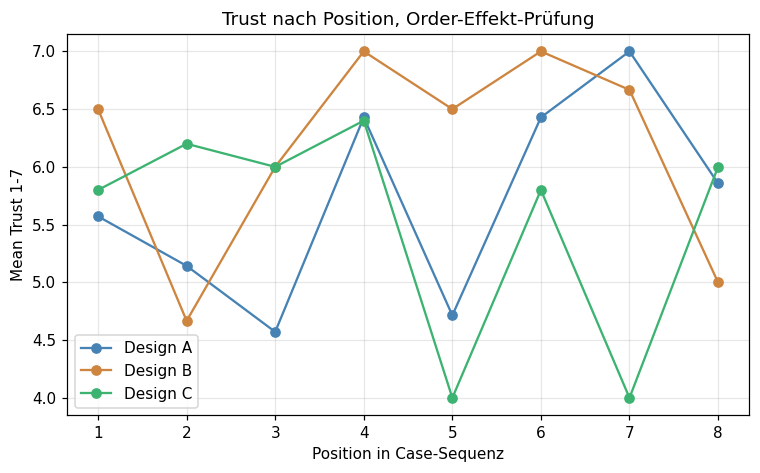

In [18]:
case_order = {'A': ['C01','C04','C08','C02','C05','C06','C03','C07'],
              'B': ['C02','C05','C06','C03','C07','C01','C04','C08'],
              'C': ['C03','C07','C01','C04','C08','C02','C05','C06']}
long_df_order = long_df.copy()
long_df_order['position'] = long_df_order.apply(lambda r: case_order.get(r['design'], []).index(r['case']) + 1 if r['case'] in case_order.get(r['design'], []) else np.nan, axis=1)
fig, ax = plt.subplots(figsize=(8, 4.5))
for d, color in zip(['A', 'B', 'C'], ['steelblue', 'peru', 'mediumseagreen']):
    sub = long_df_order[long_df_order['design'] == d]
    means = sub.groupby('position')['trust_rating'].mean()
    ax.plot(means.index, means.values, marker='o', label=f'Design {d}', color=color)
ax.set_xlabel('Position in Case-Sequenz')
ax.set_ylabel('Mean Trust 1-7')
ax.set_xticks(range(1, 9))
ax.set_title('Trust nach Position, Order-Effekt-Prüfung')
ax.legend()
ax.grid(True, alpha=0.3)
save_plot(fig, '13-counterbalance-order-effect')
plt.show()

## Plot 14, Decision-Time-Verteilung pro Case

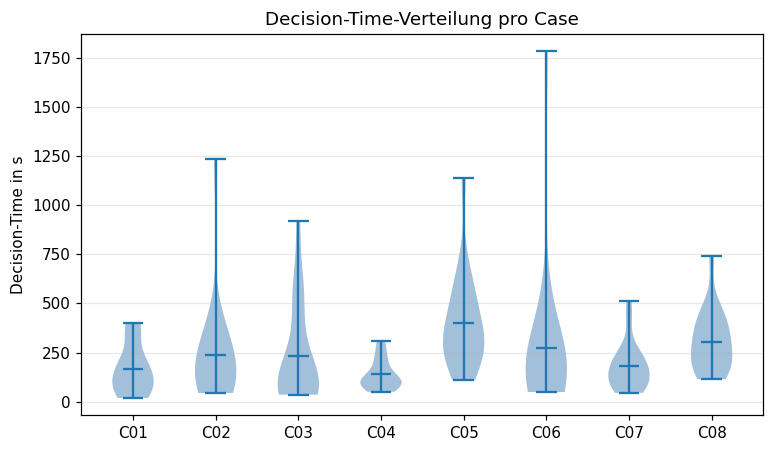

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.5))
cases_list = sorted(long_df['case'].unique())
data = [long_df[long_df['case'] == c]['decision_time_s'].dropna().values for c in cases_list]
parts = ax.violinplot(data, positions=range(len(cases_list)), showmeans=True, showmedians=False)
for pc in parts['bodies']:
    pc.set_facecolor('steelblue')
    pc.set_alpha(0.5)
ax.set_xticks(range(len(cases_list)))
ax.set_xticklabels(cases_list)
ax.set_ylabel('Decision-Time in s')
ax.set_title('Decision-Time-Verteilung pro Case')
ax.grid(True, axis='y', alpha=0.3)
save_plot(fig, '14-decision-time-distribution')
plt.show()

## Plot 15, Group-x-Variant-Heterogenität

Mean +/- SE pro Variante für Trust und Control, getrennt nach Citizen-Devs (n=8) und Professional-Devs (n=10). Diagnostik-Tabelle der Lifts pro Gruppe unten.

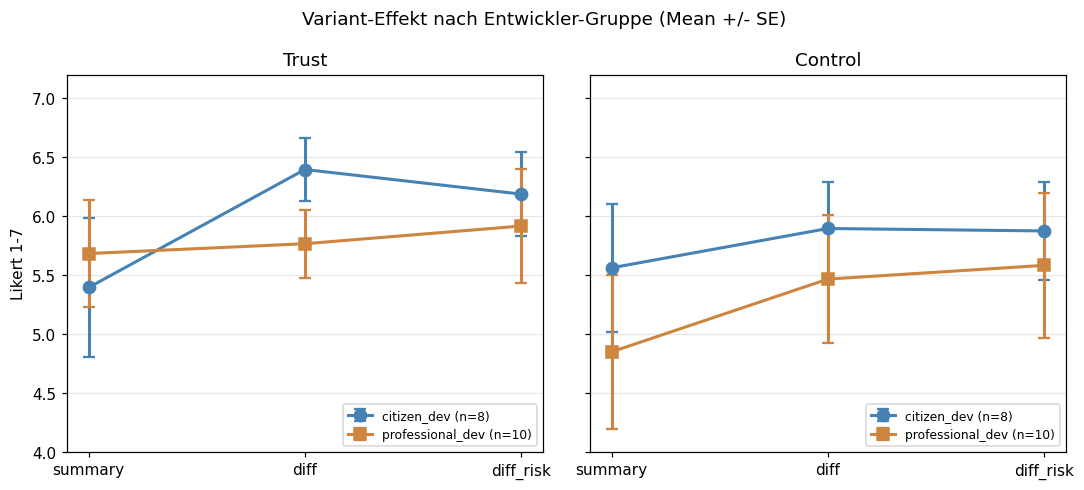

,item,group,n,summary_mean,diff_mean,diff_risk_mean,lift_diff,lift_diff_risk
0,Trust,citizen_dev,8,5.40,6.40,6.19,1.00,0.79
1,Trust,professional_dev,10,5.68,5.77,5.92,0.08,0.23
2,Control,citizen_dev,8,5.56,5.90,5.88,0.33,0.31
3,Control,professional_dev,10,4.85,5.47,5.58,0.62,0.73


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
for ax, (col, label) in zip(axes, [('trust_rating', 'Trust'), ('control_rating', 'Control')]):
    for g, color, marker in [('citizen_dev', 'steelblue', 'o'), ('professional_dev', 'peru', 's')]:
        pid_var = (long_df[long_df['group'] == g]
              .groupby(['pid', 'variant'])[col].mean().unstack()[VARIANT_ORDER].dropna())
        ax.errorbar(VARIANT_ORDER, pid_var.mean(), yerr=pid_var.sem(), marker=marker, label=f'{g} (n={len(pid_var)})',
                    color=color, linewidth=2, markersize=8, capsize=4, capthick=1.5)
    ax.set_title(label)
    ax.set_ylabel('Likert 1-7' if col == 'trust_rating' else '')
    ax.set_ylim(4.0, 7.2)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(fontsize=8, loc='lower right')
fig.suptitle('Variant-Effekt nach Entwickler-Gruppe (Mean +/- SE)')
fig.tight_layout()
save_plot(fig, '15-group-variant-heterogeneity')
plt.show()

diag_rows = []
for col, label in [('trust_rating', 'Trust'), ('control_rating', 'Control')]:
    for g in ['citizen_dev', 'professional_dev']:
        pid_var = (long_df[long_df['group'] == g]
              .groupby(['pid', 'variant'])[col].mean().unstack()[VARIANT_ORDER].dropna())
        diag_rows.append({
            'item': label, 'group': g, 'n': len(pid_var),
            'summary_mean': round(pid_var['summary'].mean(), 2),
            'diff_mean': round(pid_var['diff'].mean(), 2),
            'diff_risk_mean': round(pid_var['diff_risk'].mean(), 2),
            'lift_diff': round((pid_var['diff'] - pid_var['summary']).mean(), 2),
            'lift_diff_risk': round((pid_var['diff_risk'] - pid_var['summary']).mean(), 2),
        })
pd.DataFrame(diag_rows)

## Plot 16, Mass-Operation-Sensitivity

Mean-Differenz `diff_risk` minus `summary` pro Item mit Bootstrap-95-Prozent-CI, einmal über alle 8 Cases und einmal ohne C05/C08 (die zwei Bulk-Operation-Cases). Friedman-p-Diagnostik unten.

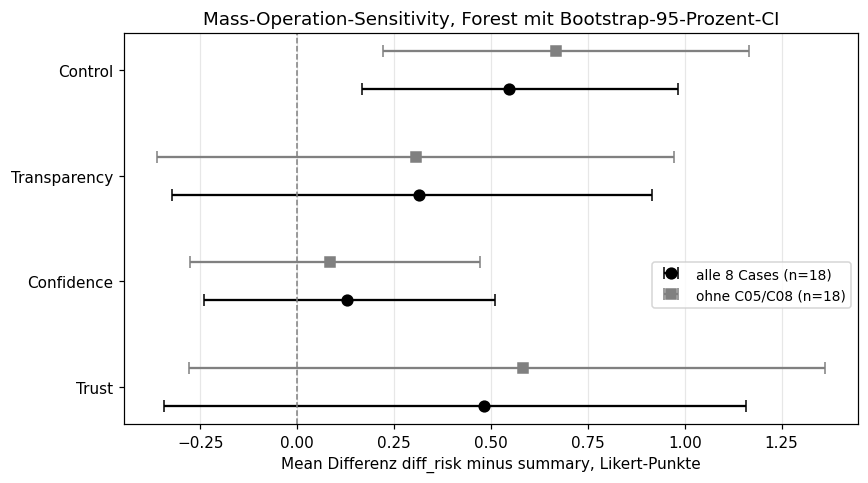

,item,cond,chi2,p,n
0,Trust,alle 8 Cases,5.93,0.0515,18
1,Confidence,alle 8 Cases,1.06,0.5896,18
2,Transparency,alle 8 Cases,1.34,0.5105,18
3,Control,alle 8 Cases,5.70,0.0579,18
4,Trust,ohne C05/C08,5.29,0.0712,18
5,Confidence,ohne C05/C08,0.15,0.9277,18
6,Transparency,ohne C05/C08,0.04,0.9798,18
7,Control,ohne C05/C08,2.73,0.2548,18


In [21]:
conditions = [
    ('alle 8 Cases', long_df),
    ('ohne C05/C08', long_df[~long_df['case'].isin(['C05', 'C08'])]),
]
sens_rows = []
for cond_name, df in conditions:
    for col, label in ITEM_LABELS.items():
        pid_var = df.groupby(['pid', 'variant'])[col].mean().unstack()[VARIANT_ORDER].dropna()
        diffs = (pid_var['diff_risk'] - pid_var['summary']).values
        m, lo, hi = bootstrap_mean_ci(diffs)
        sens_rows.append({'item': label, 'cond': cond_name, 'n': len(pid_var), 'mean': m, 'lo': lo, 'hi': hi})
sens_df = pd.DataFrame(sens_rows)

fig, ax = plt.subplots(figsize=(8, 4.5))
items = list(ITEM_LABELS.values())
y_full = np.arange(len(items)) - 0.18
y_red = np.arange(len(items)) + 0.18
vals_full = sens_df[sens_df['cond'] == 'alle 8 Cases'].set_index('item').loc[items]
vals_red = sens_df[sens_df['cond'] == 'ohne C05/C08'].set_index('item').loc[items]

ax.errorbar(vals_full['mean'], y_full,
            xerr=[vals_full['mean'] - vals_full['lo'], vals_full['hi'] - vals_full['mean']],
            fmt='o', color='black', capsize=4, markersize=7, label='alle 8 Cases (n=18)')
ax.errorbar(vals_red['mean'], y_red,
            xerr=[vals_red['mean'] - vals_red['lo'], vals_red['hi'] - vals_red['mean']],
            fmt='s', color='gray', capsize=4, markersize=7, label='ohne C05/C08 (n=18)')
ax.set_yticks(np.arange(len(items)))
ax.set_yticklabels(items)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Mean Differenz diff_risk minus summary, Likert-Punkte')
ax.set_title('Mass-Operation-Sensitivity, Forest mit Bootstrap-95-Prozent-CI')
ax.grid(True, axis='x', alpha=0.3)
ax.legend(loc='lower right', bbox_to_anchor=(1.0, 0.28), fontsize=9)
fig.tight_layout()
save_plot(fig, '16-sensitivity-mass-operation')
plt.show()

friedman_diag = []
for cond_name, df in conditions:
    for col, label in ITEM_LABELS.items():
        pid_var = df.groupby(['pid', 'variant'])[col].mean().unstack()[VARIANT_ORDER].dropna()
        chi2, p = stats.friedmanchisquare(pid_var['summary'], pid_var['diff'], pid_var['diff_risk'])
        friedman_diag.append({'item': label, 'cond': cond_name, 'chi2': round(chi2, 2), 'p': round(p, 4), 'n': len(pid_var)})
pd.DataFrame(friedman_diag)

## Anhang-Tabellen

Aggregat-Tabellen, exportiert nach [../tables/](../tables/).

In [22]:
from pathlib import Path
ANHANG = Path('../tables')
ANHANG.mkdir(parents=True, exist_ok=True)

by_case_full = long_df.groupby('case').agg(
    gt=('case_gt_decision', 'first'),
    risk_class=('case_risk_class', 'first'),
    tech_succ_rate=('tech_succeeded', 'mean'),
    user_compliance_rate=('correct_vs_gt', 'mean'),
    trust_mean=('trust_rating', 'mean'),
    time_mean=('decision_time_s', 'mean'),
    approval_triggered_n=('outcome_cat', lambda x: (x == 'approval_triggered').sum()),
    hard_blocked_n=('outcome_cat', lambda x: (x == 'hard_blocked').sum()),
    auto_approved_n=('outcome_cat', lambda x: (x == 'auto_approved').sum()),
    no_action_n=('outcome_cat', lambda x: (x == 'no_action').sum()),
    n=('pid', 'count'),
).round(2).reset_index()
by_case_full = by_case_full.merge(perf[['class']].reset_index().rename(columns={'class': 'msl_class'}), on='case')
by_case_full.to_csv(ANHANG / 'tab-pro-case.csv', index=False)

rows = []
for var in VARIANT_ORDER:
    sub = long_df[long_df['variant'] == var]
    rec = {'variant': var, 'n': len(sub)}
    for col, label in ITEM_LABELS.items():
        m, lo, hi = bootstrap_mean_ci(sub[col])
        rec[f'{label}_mean'] = round(m, 2)
        rec[f'{label}_ci'] = f'{lo:.2f} bis {hi:.2f}'
    rec['time_mean'] = round(sub['decision_time_s'].mean(), 1)
    rows.append(rec)
var_table = pd.DataFrame(rows)
var_table.to_csv(ANHANG / 'tab-pro-variant.csv', index=False)

desc_table.to_csv(ANHANG / 'tab-deskriptiv.csv', index=False)
inference_table.to_csv(ANHANG / 'tab-inferenz.csv', index=False)

print('Anhang-CSVs geschrieben nach', ANHANG)
print()
print(by_case_full)

Anhang-CSVs geschrieben nach ../tables

  case       gt risk_class  tech_succ_rate  user_compliance_rate  trust_mean  \
0  C01  approve        low            0.94                  1.00        6.17   
1  C02  approve        low            1.00                  1.00        6.28   
2  C03  approve    low_med            1.00                  1.00        6.67   
3  C04   reject       high            0.94                  0.06        6.00   
4  C05   reject   med_high            0.22                  0.11        4.50   
5  C06   reject       high            1.00                  0.00        6.17   
6  C07   reject       high            0.89                  0.00        6.17   
7  C08  approve        med            1.00                  1.00        4.56   

   time_mean  approval_triggered_n  hard_blocked_n  auto_approved_n  \
0     166.97                     0               1               17   
1     236.08                     0               0               18   
2     230.18              

## Zusammenfassung

Plots in [../figures/](../figures/), Aggregat-Tabellen in [../tables/](../tables/). Reproduktion mit `Restart and Run All`.